In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

X = torch.randn(200, 2)
y = ((X[:, 0]**2 + X[:, 1]**2) > 1).float().reshape(-1, 1)

In [2]:
W = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def model(X):
    return torch.sigmoid(X @ W + b)

def loss_fn(pred, y):
    return -(y * torch.log(pred + 1e-8) +
             (1-y) * torch.log(1-pred + 1e-8)).mean()

In [3]:
def momentum_update(W, b, dW, db, vW, vb, lr=0.01, beta=0.9):

    vW = beta * vW + (1-beta) * dW
    vb = beta * vb + (1-beta) * db

    W = W - lr * vW
    b = b - lr * vb

    return W, b, vW, vb

In [4]:
def rmsprop_update(W, b, dW, db, sW, sb,
                   lr=0.01, beta=0.9):

    sW = beta * sW + (1-beta) * dW**2
    sb = beta * sb + (1-beta) * db**2

    W = W - lr * dW / (torch.sqrt(sW) + 1e-8)
    b = b - lr * db / (torch.sqrt(sb) + 1e-8)

    return W, b, sW, sb

In [5]:
def adam_update(W, b, dW, db, mW, mb, vW, vb, t,
                lr=0.01, beta1=0.9, beta2=0.999):

    mW = beta1*mW + (1-beta1)*dW
    mb = beta1*mb + (1-beta1)*db

    vW = beta2*vW + (1-beta2)*dW**2
    vb = beta2*vb + (1-beta2)*db**2

    mWh = mW / (1-beta1**t)
    mbh = mb / (1-beta1**t)

    vWh = vW / (1-beta2**t)
    vbh = vb / (1-beta2**t)

    W = W - lr*mWh/(torch.sqrt(vWh)+1e-8)
    b = b - lr*mbh/(torch.sqrt(vbh)+1e-8)

    return W, b, mW, mb, vW, vb

In [6]:
W = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

mW = torch.zeros_like(W)
mb = torch.zeros_like(b)
vW = torch.zeros_like(W)
vb = torch.zeros_like(b)

losses = []

for t in range(1, 501):

    pred = model(X)
    loss = loss_fn(pred, y)

    loss.backward()

    with torch.no_grad():
        W, b, mW, mb, vW, vb = adam_update(
            W, b, W.grad, b.grad,
            mW, mb, vW, vb, t
        )

    W = W.detach().requires_grad_()
    b = b.detach().requires_grad_()

    losses.append(loss.item())

    if t % 100 == 0:
        print(f"Step {t}, Loss: {loss.item():.4f}")

Step 100, Loss: 0.6716
Step 200, Loss: 0.6683
Step 300, Loss: 0.6683
Step 400, Loss: 0.6683
Step 500, Loss: 0.6683


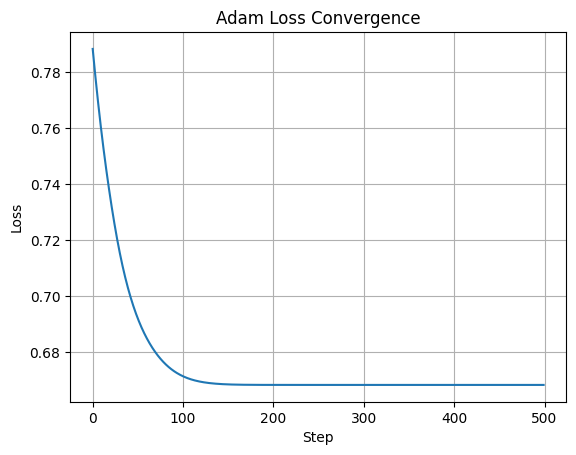

In [7]:
plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Adam Loss Convergence")
plt.grid()
plt.show()

In [8]:
print("Custom Momentum, RMSprop and Adam implementations completed.")
print("Adam bias correction and loss convergence were demonstrated.")

Custom Momentum, RMSprop and Adam implementations completed.
Adam bias correction and loss convergence were demonstrated.
